## Data preparation

Plate reader data is loaded using `pr.load_platereader_data`, which parses the raw instrument 
output and merges the platemap to annotate each well with its construct identity.

Note: the tMangoIV and tMangoIV-RiboJ construct labels are suspected to be swapped in the 
platemap. A repeat experiment is pending to confirm.

In [1]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pr.plot_setup()

In [2]:
data, platemap = pr.load_platereader_data(
    data_file="20251027_Broccoli_mScarlet_test.txt",
    platemap_file="20251027_Broccoli_mScarlet_platemap.tsv",
    platereader="biotek-cdk"
)

# Background subtraction — remove negative control signal from all wells at each timepoint
neg_mean = data[data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].mean()
data["Data"] = data.apply(
    lambda row: row["Data"] - neg_mean.loc[(row["Time"], row["Read"])], axis=1
)
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

# Save background-subtracted data
data.to_csv("20251027_Broccoli_mScarlet_data_Background_Sbtrkt.csv", index=True)
print(f"Saved background-subtracted data: {len(data)} rows")

Saved background-subtracted data: 2160 rows


## Timecourse analysis

### Full timecourse
The full timecourse plots show the raw fluorescence data for each construct across the entire 
experiment duration, excluding the negative control. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval. The aptamer reporter 
(transcription) and mScarlet (translation) are plotted separately.

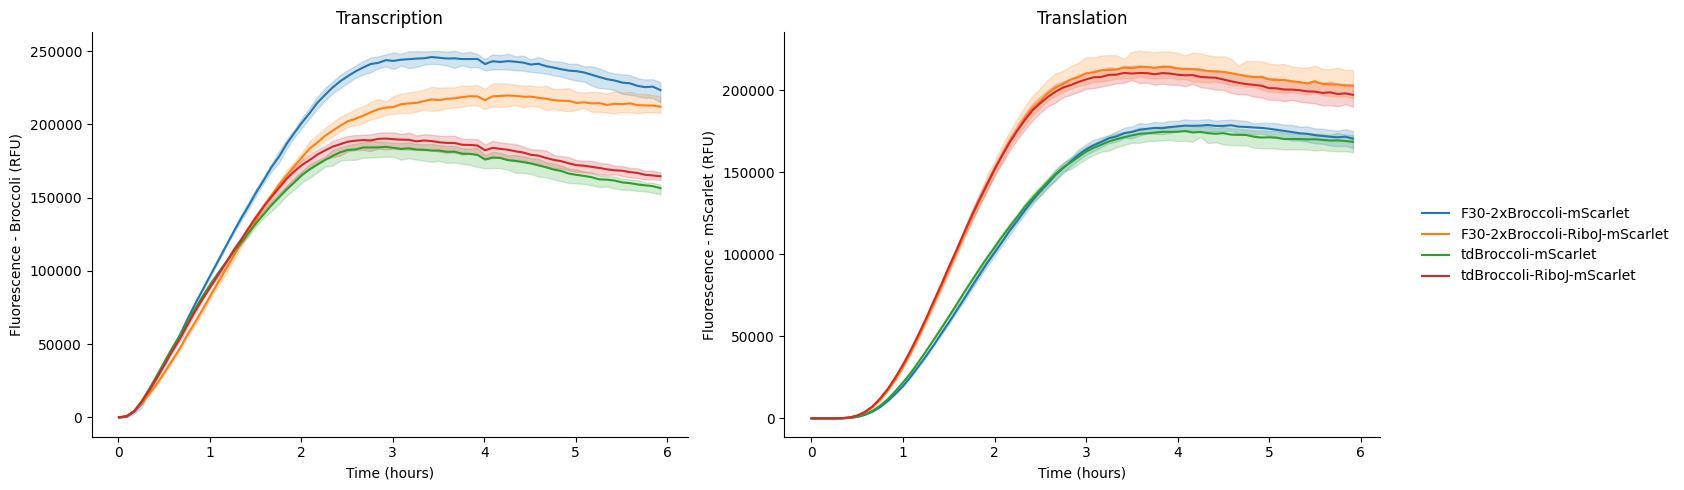

In [3]:
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, read, ylabel in [
    (axes[0], "GFP-Gext", "Fluorescence - Broccoli (RFU)"),
    (axes[1], "mScarlet", "Fluorescence - mScarlet (RFU)")
]:
    subset = data[(data["Read"] == read) & (data["Name"] != "Negative")]
    sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name", ax=ax)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

axes[0].set_title("Transcription")
axes[1].set_title("Translation")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False)
sns.despine()
plt.tight_layout()
#plt.savefig("./figures/Broccoli_mScarlet_full_timecourse.png", dpi=600, bbox_inches="tight")
plt.show()

### First hour
The first-hour plots show the early period of the experiment, split by aptamer variant to allow 
direct comparison of RiboJ and non-RiboJ constructs. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval.

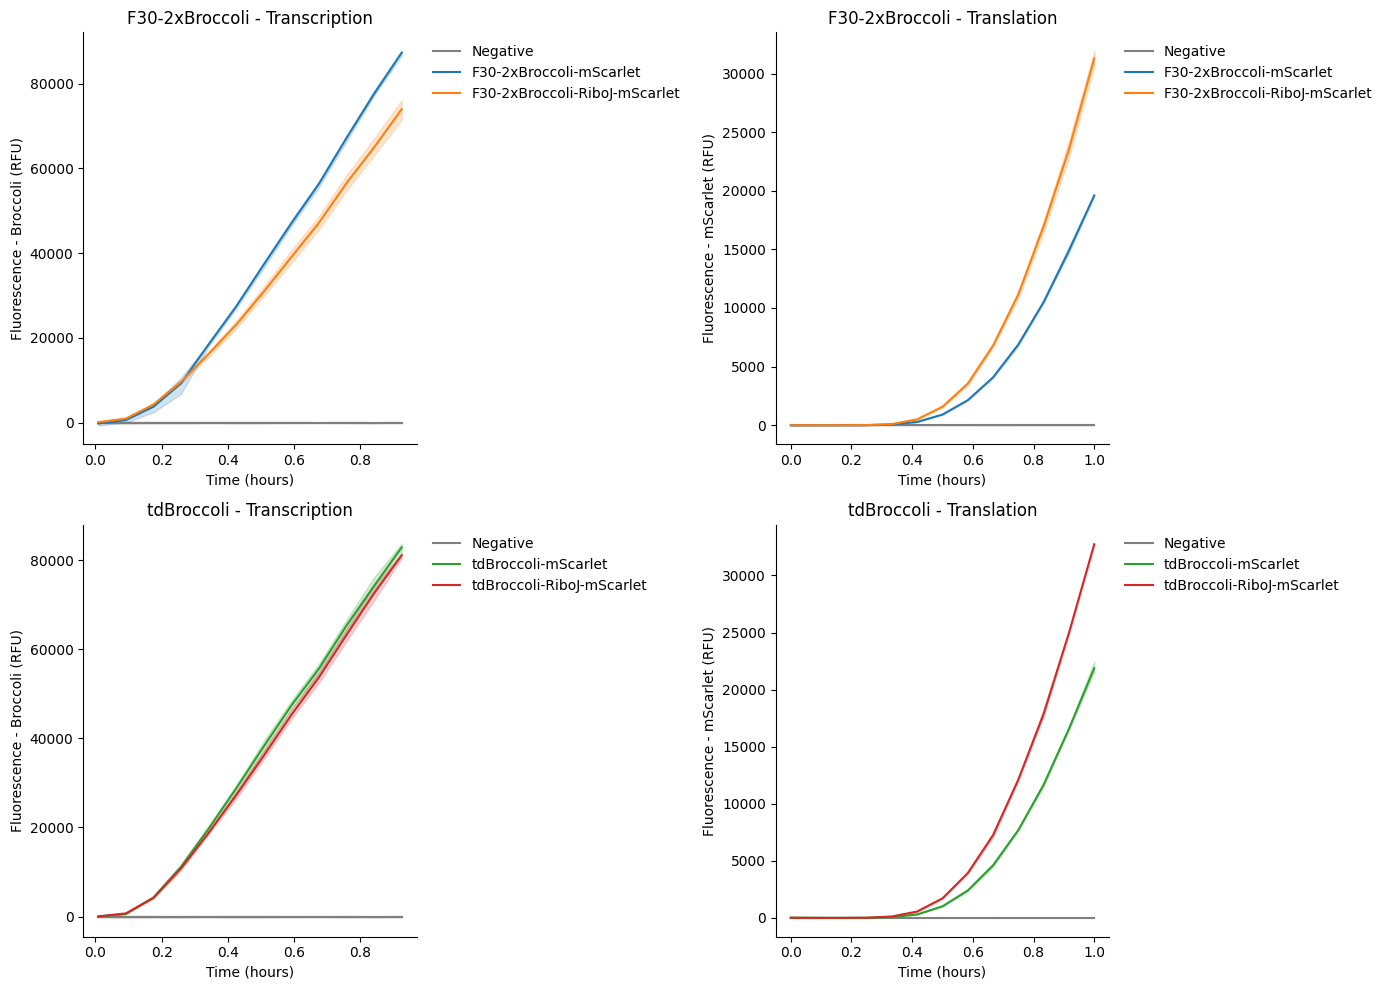

In [4]:
broccoli_colours = {
    "F30-2xBroccoli-mScarlet": "tab:blue",
    "F30-2xBroccoli-RiboJ-mScarlet": "tab:orange",
    "tdBroccoli-mScarlet": "tab:green",
    "tdBroccoli-RiboJ-mScarlet": "tab:red",
    "Negative": "tab:grey"
}
variants = {"F30-2xBroccoli": 0, "tdBroccoli": 1}
one_hour = pd.Timedelta("1 hour")
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for variant, row in variants.items():
    names = list(data[data["Name"].str.contains(variant)]["Name"].unique()) + ["Negative"]
    for col, read, ylabel in [(0, "GFP-Gext", "Fluorescence - Broccoli (RFU)"),
                               (1, "mScarlet", "Fluorescence - mScarlet (RFU)")]:
        subset = data[
            (data["Read"] == read) &
            (data["Name"].isin(names)) &
            (data["Time"] <= one_hour)
        ]
        sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name",
                     palette={n: broccoli_colours[n] for n in names},
                     ax=axes[row, col])
        axes[row, col].set_xlabel("Time (hours)")
        axes[row, col].set_ylabel(ylabel)
        axes[row, col].get_legend().remove()
    axes[row, 0].set_title(f"{variant} - Transcription")
    axes[row, 1].set_title(f"{variant} - Translation")
    for col in [0, 1]:
        handles, labels = axes[row, col].get_legend_handles_labels()
        axes[row, col].legend(handles, labels, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.savefig("./figures/Broccoli_mScarlet_first_hour_Background_sbtrkt.png", dpi=600, bbox_inches="tight")
plt.show()

## Kinetic analysis

Sigmoid drift curves are fitted to each replicate well individually using `pr.kinetic_analysis`. 
Lag times are extracted as the x-intercept of the tangent line at the inflection point of the 
fitted sigmoid. Lag times for the transcription reporter and mScarlet are plotted side by side 
per construct with error bars representing standard deviation across three replicate wells. The 
translation initiation delay is calculated as the difference between the mScarlet lag time and 
the aptamer lag time.

PROVIDING AVERAGED KINETICS
PROVIDING AVERAGED KINETICS


Text(0.5, 1.02, 'DFHBI-1T — Transcription')

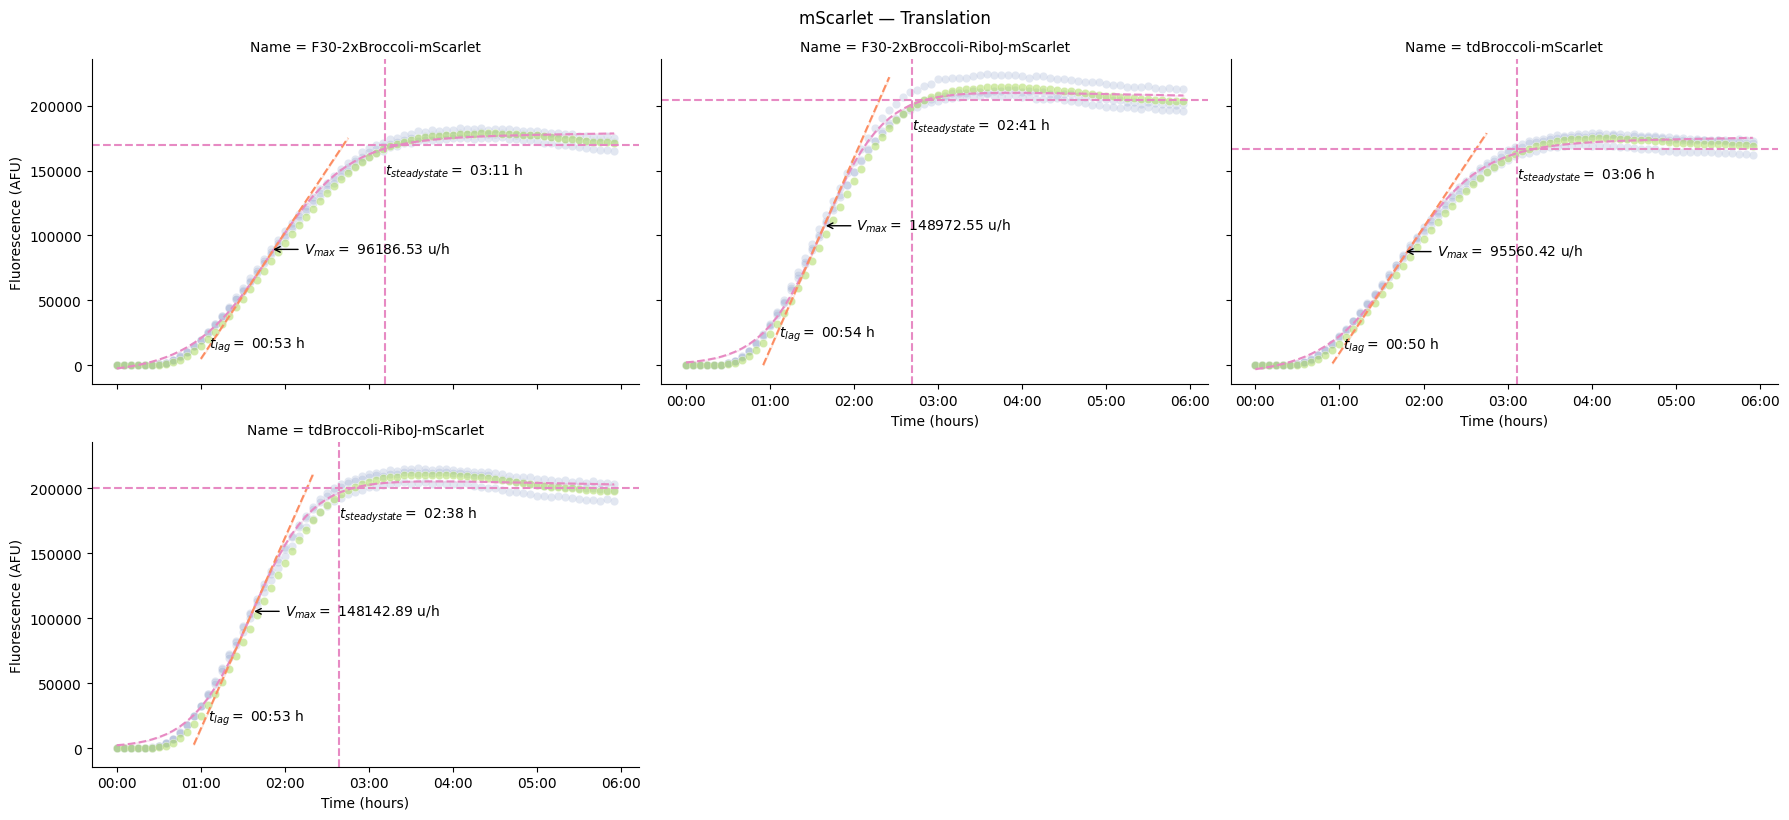

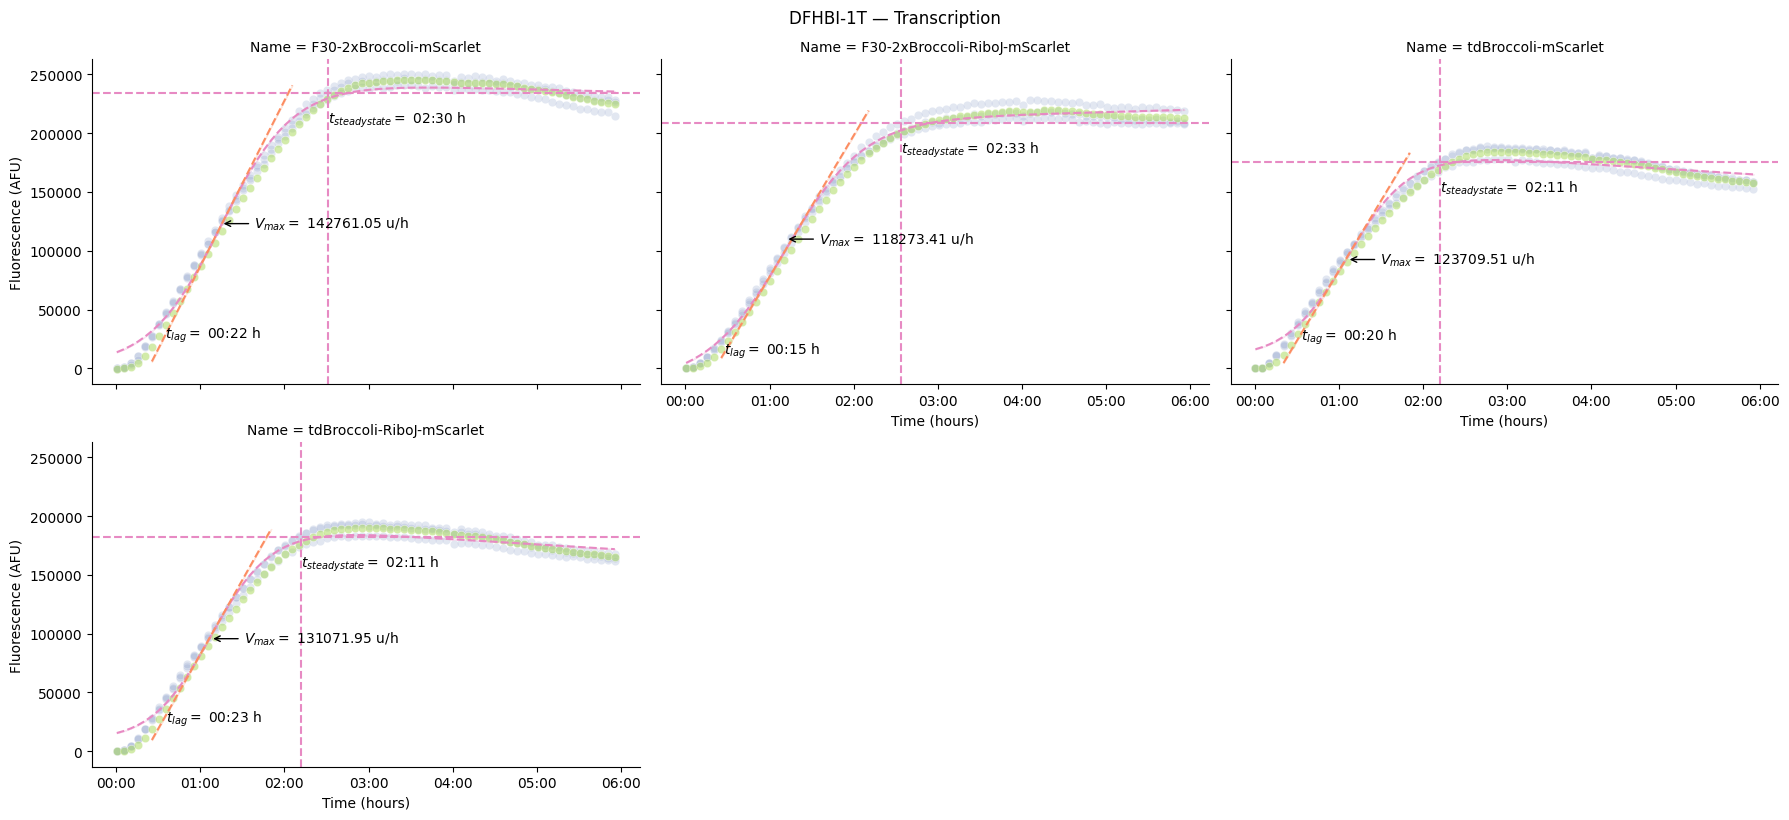

In [11]:
mScarlet_kinetics_plot, _ = pr.plot_kinetics(
    data[(data["Name"] != "Negative") & (data["Read"] == "mScarlet")],
    group_by=["Name", "Read"]
)
mScarlet_kinetics_plot.fig.suptitle("mScarlet — Translation", y=1.02)
#mScarlet_kinetics_plot.fig.savefig("./figures/Broccoli_mScarlet_kinetics.png", dpi=600, bbox_inches="tight")

broccoli_kinetics_plot, _ = pr.plot_kinetics(
    data[(data["Name"] != "Negative") & (data["Read"] == "GFP-Gext")],
    group_by=["Name", "Read"]
)
broccoli_kinetics_plot.fig.suptitle("DFHBI-1T — Transcription", y=1.02)
#broccoli_kinetics_plot.fig.savefig("./figures/Broccoli_DFHBI-1T_kinetics.png", dpi=600, bbox_inches="tight")

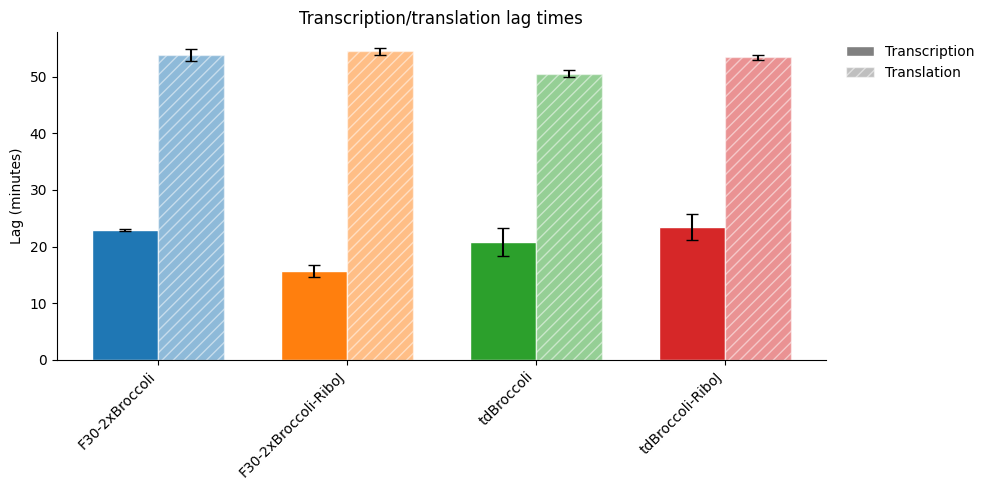

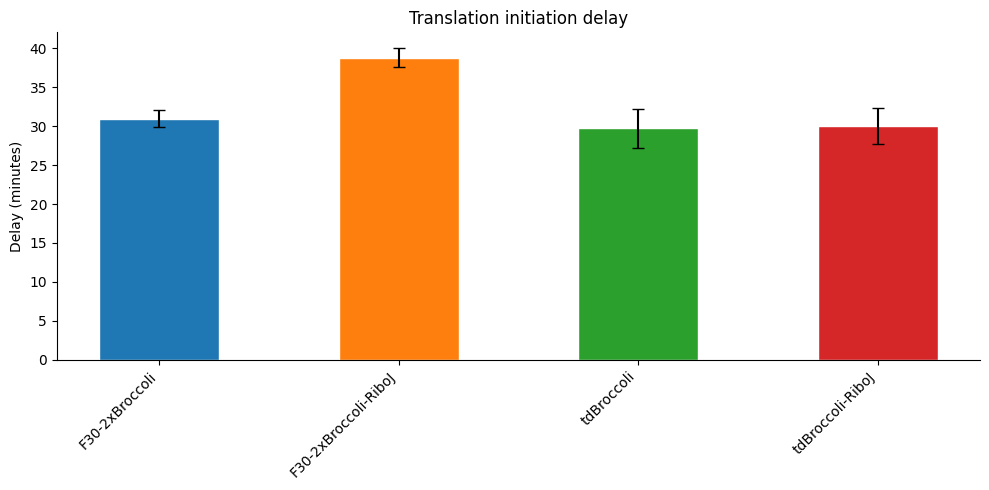

In [6]:
# Kinetic analysis using pr.kinetic_analysis
kinetics = pr.kinetic_analysis(data[data["Name"] != "Negative"], group_by=["Name", "Read", "Well"])

# Extract lag times in minutes
mScarlet_lag = kinetics.xs("mScarlet", level="Read")["Lag"]["Time"].dt.total_seconds() / 60
broccoli_lag = kinetics.xs("GFP-Gext", level="Read")["Lag"]["Time"].dt.total_seconds() / 60
broccoli_lag = broccoli_lag.clip(lower=0)

# Means and stds
mScarlet_mean = mScarlet_lag.groupby("Name").mean()
mScarlet_std = mScarlet_lag.groupby("Name").std()
broccoli_mean = broccoli_lag.groupby("Name").mean()
broccoli_std = broccoli_lag.groupby("Name").std()

# Save copies before plotting code can overwrite these variables
broccoli_lag_mean_saved = broccoli_mean.copy()
broccoli_lag_std_saved = broccoli_std.copy()
mScarlet_lag_mean_saved = mScarlet_mean.copy()
mScarlet_lag_std_saved = mScarlet_std.copy()

# Translation initiation delay
delay_mean = mScarlet_mean - broccoli_mean
delay_std = (mScarlet_std**2 + broccoli_std**2)**0.5

# Lag times plot
from matplotlib.patches import Patch
construct_colours = {
    "F30-2xBroccoli": "tab:blue",
    "F30-2xBroccoli-RiboJ": "tab:orange",
    "tdBroccoli": "tab:green",
    "tdBroccoli-RiboJ": "tab:red"
}

fig, ax = plt.subplots(figsize=(10, 5))
constructs = list(construct_colours.keys())
width = 0.35

for i, construct in enumerate(constructs):
    colour = construct_colours[construct]
    trans_mean = broccoli_mean.get(construct + "-mScarlet", 0)
    trans_std = broccoli_std.get(construct + "-mScarlet", 0)
    ax.bar(i - width/2, trans_mean, width, color=colour,
           yerr=trans_std, capsize=4, edgecolor="white")
    mscarlet_mean_val = mScarlet_mean.get(construct + "-mScarlet", 0)
    mscarlet_std_val = mScarlet_std.get(construct + "-mScarlet", 0)
    ax.bar(i + width/2, mscarlet_mean_val, width, color=colour, hatch="///",
           edgecolor="white", yerr=mscarlet_std_val, capsize=4, alpha=0.5)

ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha="right")
ax.set_ylabel("Lag (minutes)")
ax.set_title("Transcription/translation lag times")
legend_elements = [
    Patch(facecolor="grey", edgecolor="white", label="Transcription"),
    Patch(facecolor="grey", hatch="///", edgecolor="white", alpha=0.5, label="Translation")
]
ax.legend(handles=legend_elements, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

# Translation initiation delay plot
fig, ax = plt.subplots(figsize=(10, 5))
for i, construct in enumerate(constructs):
    colour = construct_colours[construct]
    mean_val = delay_mean.get(construct + "-mScarlet", 0)
    std_val = delay_std.get(construct + "-mScarlet", 0)
    ax.bar(i, mean_val, width=0.5, color=colour, yerr=std_val, capsize=4, edgecolor="white")

ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha="right")
ax.set_ylabel("Delay (minutes)")
ax.set_title("Translation initiation delay")
sns.despine()
plt.tight_layout()
plt.show()

## Reporter QC metrics

The following table summarises key quality metrics for each construct and reporter combination.

- **Lag detectable**: whether a distinct lag phase is observable before signal onset. A 
  detectable lag phase is required to determine transcription or translation initiation time.
- **SNR** (signal-to-noise ratio): fitted steady-state signal divided by the noise floor of 
  the negative control after background subtraction. Higher values indicate cleaner signal 
  above background noise.
- **R²**: goodness-of-fit of the sigmoid model to the timecourse data. Values close to 1.0 
  indicate the sigmoid accurately describes the kinetics and lag time extraction is reliable.
- **Lag mean (min)**: mean fitted lag time across replicate wells — the time from reaction 
  start to detectable signal onset.
- **Lag std (min)**: standard deviation of lag times across replicate wells in minutes. Lower 
  values indicate more reproducible timing measurements.
- **Lag CV (%)**: coefficient of variation of the lag time (lag std / lag mean × 100). Lower 
  values indicate the timing measurement uncertainty is small relative to the lag time itself.
- **Drift rate (RFU/h)**: the rate of signal change after steady state, extracted directly 
  from the sigmoid drift model fit. Values close to zero indicate a stable signal after the 
  reaction completes. Negative values indicate signal decay due to effects such as 
  photobleaching or evaporation, while positive values indicate continued signal increase.


In [7]:
# QC Metrics Table
# Steady state SNR — using noise floor after background subtraction
steady_state_broccoli = pr.find_steady_state(data, group_by=["Name", "Read", "Well"])
ss_data = steady_state_broccoli["Data_steadystate"]
noise = data[data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].std().groupby("Read").mean()
signal = ss_data.groupby(["Name", "Read"]).mean().drop("Negative", level="Name")
snr = signal / noise

# R² from kinetics
r2 = kinetics["Fit"]["R^2"].groupby(["Name", "Read"]).mean()
r2.index.names = ["Name", "Read"]

# Drift rate from kinetics fit
drift = kinetics["Fit"]["drift"].groupby(["Name", "Read"]).mean()
drift.index.names = ["Name", "Read"]
drift = drift.drop("Negative", level="Name", errors="ignore")

# Lag times
broccoli_lag_indexed = broccoli_lag_mean_saved.rename_axis("Name").to_frame("Lag mean (min)").assign(Read="GFP-Gext").set_index("Read", append=True)["Lag mean (min)"]
mScarlet_lag_indexed = mScarlet_lag_mean_saved.rename_axis("Name").to_frame("Lag mean (min)").assign(Read="mScarlet").set_index("Read", append=True)["Lag mean (min)"]
broccoli_std_indexed = broccoli_lag_std_saved.rename_axis("Name").to_frame("Lag std (min)").assign(Read="GFP-Gext").set_index("Read", append=True)["Lag std (min)"]
mScarlet_std_indexed = mScarlet_lag_std_saved.rename_axis("Name").to_frame("Lag std (min)").assign(Read="mScarlet").set_index("Read", append=True)["Lag std (min)"]

# Compile table
broccoli_table = pd.DataFrame({
    "SNR": snr.round(2),
    "R²": r2.round(4),
    "Drift rate (RFU/h)": drift.round(2),
})
broccoli_table["Lag mean (min)"] = pd.concat([broccoli_lag_indexed, mScarlet_lag_indexed]).round(1)
broccoli_table["Lag std (min)"] = pd.concat([broccoli_std_indexed, mScarlet_std_indexed]).round(1)
broccoli_table["Lag CV (%)"] = (broccoli_table["Lag std (min)"] / broccoli_table["Lag mean (min)"] * 100).round(1)
broccoli_table["Lag detectable"] = ["Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"]
broccoli_table = broccoli_table[[
    "Lag detectable", "SNR", "R²", "Lag mean (min)",
    "Lag std (min)", "Lag CV (%)", "Drift rate (RFU/h)"
]]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(broccoli_table)

Failed to solve for group ('Negative', 'GFP-Gext', 'D3'): An upper bound is less than the corresponding lower bound.


                                       Lag detectable      SNR   R²  Lag mean (min)  Lag std (min)  Lag CV (%)  Drift rate (RFU/h)
Name                          Read                                                                                                
F30-2xBroccoli-RiboJ-mScarlet GFP-Gext            Yes  1268.23 1.00           15.70           1.10        7.00             1930.61
                              mScarlet            Yes 49371.77 1.00           54.50           0.60        1.10            -1215.37
F30-2xBroccoli-mScarlet       GFP-Gext            Yes  1420.15 0.99           22.90           0.20        0.90            -1886.70
                              mScarlet            Yes 41013.88 1.00           53.90           1.10        2.00              970.40
tdBroccoli-RiboJ-mScarlet     GFP-Gext            Yes  1103.82 0.99           23.40           2.30        9.80            -4436.44
                              mScarlet            Yes 48404.72 1.00           53.40

## Per-well kinetic fits

Individual sigmoid fits are shown for each replicate well to obtain a more accurate assessment 
of the aptamer lag time variance. Each plot shows the raw data points, the fitted sigmoid curve, 
the velocity tangent line at the inflection point, and the fitted lag time annotation. Constructs 
are grouped by aptamer variant with wells ordered by row (D, F, H).

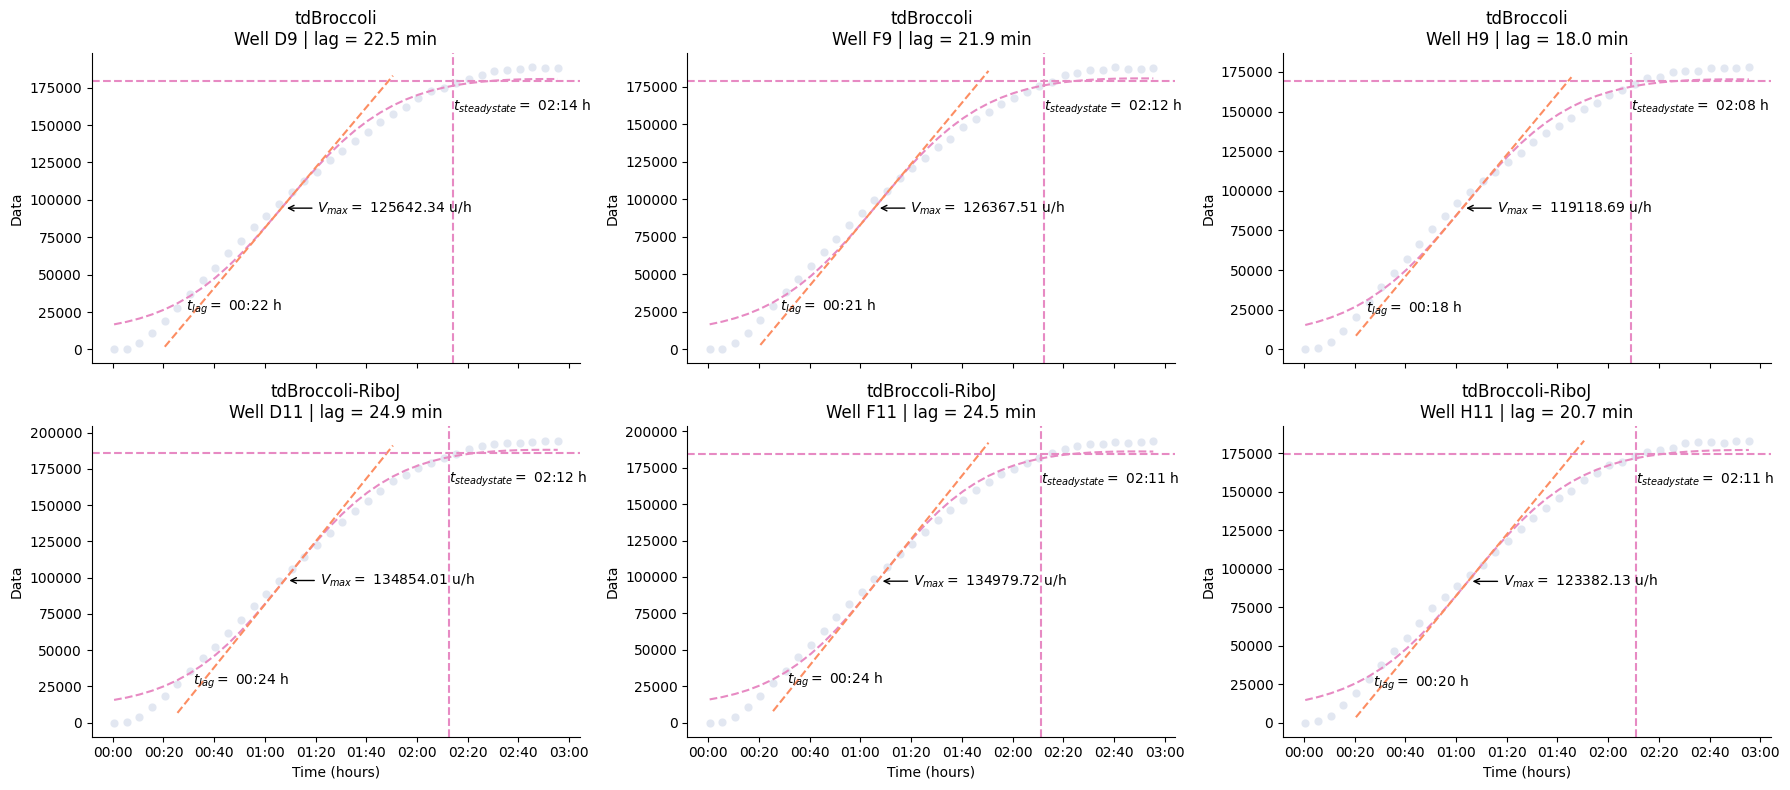

In [9]:
# tdBroccoli per-well kinetics
td_subset = data[
    (data["Name"].isin(["tdBroccoli-mScarlet", "tdBroccoli-RiboJ-mScarlet"])) &
    (data["Read"] == "GFP-Gext") &
    (data["Time"] <= pd.Timedelta("3 hours"))
].copy()

well_order_td = ["D9", "F9", "H9", "D11", "F11", "H11"]
td_subset["Well"] = pd.Categorical(td_subset["Well"], categories=well_order_td, ordered=True)
td_subset = td_subset.sort_values("Well")

g = sns.FacetGrid(td_subset, col="Well", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(pr.plot_kinetics_by_well, kinetics=kinetics,
                group_by=["Name", "Read", "Well"], show_fit=True, annotate=True)

for ax in g.axes.flat:
    title = ax.get_title()
    well = title.split(" = ")[1].strip()
    name = td_subset[td_subset["Well"] == well]["Name"].iloc[0]
    lag = kinetics.loc[(name, "GFP-Gext", well), "Lag"]["Time"].total_seconds() / 60
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well} | lag = {lag:.1f} min")

plt.tight_layout()
plt.show()

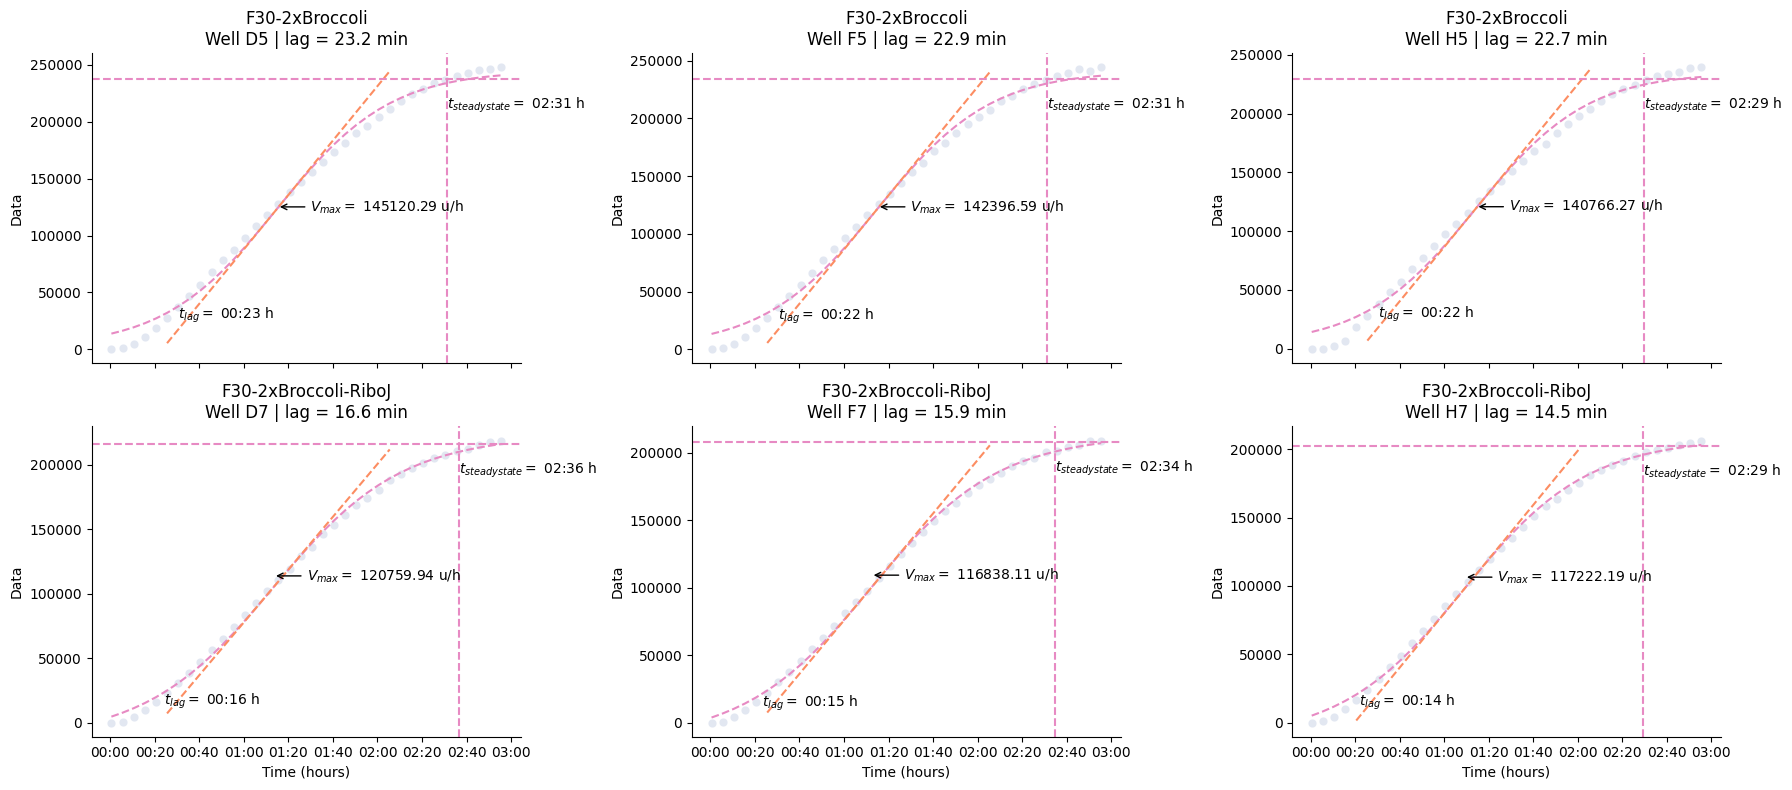

In [10]:
# F30-2xBroccoli per-well kinetics
f30_subset = data[
    (data["Name"].isin(["F30-2xBroccoli-mScarlet", "F30-2xBroccoli-RiboJ-mScarlet"])) &
    (data["Read"] == "GFP-Gext") &
    (data["Time"] <= pd.Timedelta("3 hours"))
].copy()

well_order_f30 = ["D5", "F5", "H5", "D7", "F7", "H7"]
f30_subset["Well"] = pd.Categorical(f30_subset["Well"], categories=well_order_f30, ordered=True)
f30_subset = f30_subset.sort_values("Well")

g = sns.FacetGrid(f30_subset, col="Well", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(pr.plot_kinetics_by_well, kinetics=kinetics,
                group_by=["Name", "Read", "Well"], show_fit=True, annotate=True)

for ax in g.axes.flat:
    title = ax.get_title()
    well = title.split(" = ")[1].strip()
    name = f30_subset[f30_subset["Well"] == well]["Name"].iloc[0]
    lag = kinetics.loc[(name, "GFP-Gext", well), "Lag"]["Time"].total_seconds() / 60
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well} | lag = {lag:.1f} min")

plt.tight_layout()
plt.show()